# Pipelines and Proper Model Validation for Classification

## Introduction


In the previous notebook, we learned the **fundamental classification workflow** using Logistic Regression. We manually handled each step: scaling, training, and prediction. While educational, this approach is tedious and error-prone.

This notebook introduces two critical improvements:

1. **Pipelines**: Automate the preprocessing + training workflow
2. **Proper Validation**: Avoid data leakage when comparing multiple algorithms

### The Problem We're Solving

**What if we want to compare multiple classification algorithms?**

A naive (and **WRONG**) approach:
```python
# Train all models
model1.fit(X_train_scaled, y_train)
model2.fit(X_train_scaled, y_train)
model3.fit(X_train_scaled, y_train)

# Compare on test set
score1 = model1.score(X_test_scaled, y_test)
score2 = model2.score(X_test_scaled, y_test)
score3 = model3.score(X_test_scaled, y_test)

# Pick the best one based on test scores
best_model = model_with_highest_test_score
```

**Why is this wrong?** By using the test set to choose the best model, we're making a decision based on test performance. The test set has influenced our final model choice, leading to optimistically biased results.

### The Data Leakage Problem

When the test set is used to compare models, tune hyperparameters, or make any decision that influences the final model. Even though the test data is never directly used for training, the feedback from test performance guides the model selection process.

### The Correct Approach: Three-Way Split

1. **Training Set**: Fit models
2. **Validation Set**: Compare and select models
3. **Test Set**: Final evaluation (use ONCE only)

### What We'll Build

We'll:
1. Use **Pipelines** to automate preprocessing + training
2. Split data properly: Train / Validation / Test
3. Compare four algorithms: Logistic Regression, KNN, Decision Tree, Random Forest
4. Select the best model using the validation set
5. Report final performance on the test set (once!)

Let's build a professional ML workflow!

## 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Multiple classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Pipeline construction - THE KEY TOOL!
from sklearn.pipeline import Pipeline

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


## 2. Load Data

In [ ]:
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Classes: {list(iris.target_names)}")
print(f"Balanced: 50 samples per class")
print("\n✓ Data loaded!")

Dataset: 150 samples, 4 features
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Balanced: 50 samples per class

✓ Data loaded!


## 3. Three-Way Data Split

### Why Three Sets?

**Training Set (60%)**:
- Used to fit models
- Each algorithm learns patterns from this data

**Validation Set (20%)**:
- Used to compare algorithms and select the best one
- Used to tune hyperparameters (later notebooks)
- Can "peek" at this set multiple times during development

**Test Set (20%)**:
- Final evaluation ONLY
- Used exactly ONCE after all decisions are made
- Simulates real-world deployment on unseen data

### Implementation Strategy

We'll split twice:
1. First split: Separate test set (20%) from rest (80%)
2. Second split: Split the rest into train (75% of 80% = 60%) and validation (25% of 80% = 20%)

In [ ]:
# First split: separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for final test
    random_state=42,
    stratify=y
)

# Second split: split remaining into train (75%) and validation (25%)
# 75% of 80% = 60% of total for training
# 25% of 80% = 20% of total for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,     # 25% of remaining = 20% of total
    random_state=42,
    stratify=y_temp
)

print("Three-Way Data Split:")
print("=" * 70)
print(f"Total samples:        {len(X)}")
print(f"Training set:         {len(X_train):3d} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set:       {len(X_val):3d} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set:             {len(X_test):3d} ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nClass distributions (should be similar):")
for i, species in enumerate(iris.target_names):
    train_count = np.sum(y_train == i)
    val_count = np.sum(y_val == i)
    test_count = np.sum(y_test == i)
    print(f"  {species:12s}: Train={train_count:2d}, Val={val_count:2d}, Test={test_count:2d}")

print("\n✓ Good split! All distributions are similar.")

Three-Way Data Split:
Total samples:        150
Training set:          90 (60.0%)
Validation set:        30 (20.0%)
Test set:              30 (20.0%)

Class distributions (should be similar):
  setosa      : Train=30, Val=10, Test=10
  versicolor  : Train=30, Val=10, Test=10
  virginica   : Train=30, Val=10, Test=10

✓ Good split! All distributions are similar.


## 4. Introduction to Pipelines

### What is a Pipeline?

A **Pipeline** chains together preprocessing steps and a final estimator into a **single object**.

**Without Pipeline** (manual approach from previous notebook):
```python
# Step 1: Create scaler
scaler = StandardScaler()
# Step 2: Fit scaler on training data
scaler.fit(X_train)
# Step 3: Transform training data
X_train_scaled = scaler.transform(X_train)
# Step 4: Train model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
# Step 5: Transform test data
X_test_scaled = scaler.transform(X_test)
# Step 6: Predict
y_pred = model.predict(X_test_scaled)
```

**With Pipeline**:
```python
# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression())
])
# Fit (automatically scales then trains)
pipeline.fit(X_train, y_train)
# Predict (automatically scales then predicts)
y_pred = pipeline.predict(X_test)
```

### Pipeline Advantages

1. **Cleaner Code**: 3 lines instead of 6+
2. **No Mistakes**: Can't forget to scale test data or accidentally use `fit_transform()` on test
3. **Consistency**: Exact same transformations applied everywhere
4. **Easy Deployment**: Save entire workflow as one object
5. **Fair Comparison**: Apply identical preprocessing to all models

### How Pipelines Work

When you call `pipeline.fit(X_train, y_train)`:
1. First step: `scaler.fit_transform(X_train)` → scaled training data
2. Second step: `classifier.fit(scaled_data, y_train)` → trained model

When you call `pipeline.predict(X_test)`:
1. First step: `scaler.transform(X_test)` → scaled test data (using training stats!)
2. Second step: `classifier.predict(scaled_data)` → predictions

**The pipeline automatically uses `transform()` (not `fit_transform()`) on new data!**

## 5. Build Pipelines for Four Algorithms

### The Four Algorithms

**1. Logistic Regression**
- Linear decision boundaries
- Fast and interpretable
- Provides probability estimates
- **Needs scaling**: Gradient-based optimization

**2. K-Nearest Neighbors (KNN)**
- Classifies based on K nearest training samples
- No explicit training phase
- **Needs scaling**: Uses Euclidean distance
- Good for non-linear boundaries

**3. Decision Tree**
- Creates hierarchical rules
- Can capture non-linear patterns
- **Doesn't need scaling**: Threshold-based splits
- Risk of overfitting

**4. Random Forest**
- Ensemble of many decision trees
- Reduces overfitting through voting
- **Doesn't need scaling**: Also threshold-based
- Usually best overall performance

### Why Scale All Models?

Even though tree-based models don't need scaling:
- **Consistency**: Fair comparison with identical preprocessing
- **No harm**: Scaling doesn't hurt tree-based models
- **Future-proofing**: Easy to add other algorithms later

In [ ]:
# Create four pipelines, one for each algorithm
pipelines = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    
    'KNN (K=5)': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=5))
    ]),
    
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),  # Not needed but included for consistency
        ('classifier', DecisionTreeClassifier(random_state=42, max_depth=5))
    ]),
    
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),  # Not needed but included for consistency
        ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
    ])
}

print("✓ Created 4 pipelines!\n")
for name, pipeline in pipelines.items():
    print(f"{name}:")
    for step_name, step in pipeline.steps:
        print(f"  → {step_name}: {type(step).__name__}")

✓ Created 4 pipelines!

Logistic Regression:
  → scaler: StandardScaler
  → classifier: LogisticRegression
KNN (K=5):
  → scaler: StandardScaler
  → classifier: KNeighborsClassifier
Decision Tree:
  → scaler: StandardScaler
  → classifier: DecisionTreeClassifier
Random Forest:
  → scaler: StandardScaler
  → classifier: RandomForestClassifier


## 6. Train All Models

Now we train all four pipelines on the **training set only**.

In [ ]:
print("Training all models...\n")
print("=" * 70)

for name, pipeline in pipelines.items():
    print(f"Training {name}...", end=" ")
    pipeline.fit(X_train, y_train)
    print("✓ Done!")

print("\n✓ All models trained successfully!")
print("   Note: Each pipeline automatically scaled data before training.")

Training all models...

Training Logistic Regression... ✓ Done!
Training KNN (K=5)... ✓ Done!
Training Decision Tree... ✓ Done!
Training Random Forest... ✓ Done!

✓ All models trained successfully!
   Note: Each pipeline automatically scaled data before training.


## 7. Evaluate on Training and Validation Sets

### The Critical Distinction

- **Training performance**: How well the model fits the training data
  - Expected to be good (the model learned from this data)
  - If poor, the model is too simple (**underfitting**)

- **Validation performance**: How well the model generalizes
  - This is what we care about!
  - Use this to **compare and select** models

- **Train-Validation gap**: Difference between training and validation scores
  - Large gap → **overfitting** (model memorized training data)
  - Small gap → good generalization

We'll use **validation set** to select the best model.

In [ ]:
# Evaluate all models on training and validation sets
results = {}

for name, pipeline in pipelines.items():
    # Predictions
    y_train_pred = pipeline.predict(X_train)
    y_val_pred = pipeline.predict(X_val)
    
    # Metrics
    results[name] = {
        'train_acc': accuracy_score(y_train, y_train_pred),
        'train_precision': precision_score(y_train, y_train_pred, average='weighted'),
        'train_recall': recall_score(y_train, y_train_pred, average='weighted'),
        'train_f1': f1_score(y_train, y_train_pred, average='weighted'),
        'val_acc': accuracy_score(y_val, y_val_pred),
        'val_precision': precision_score(y_val, y_val_pred, average='weighted'),
        'val_recall': recall_score(y_val, y_val_pred, average='weighted'),
        'val_f1': f1_score(y_val, y_val_pred, average='weighted'),
        'val_predictions': y_val_pred
    }

print("✓ Evaluation complete!")

✓ Evaluation complete!


### Display Results

Let's compare all four models side by side.

In [ ]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Algorithm': results.keys(),
    'Train Acc': [f"{results[name]['train_acc']:.4f}" for name in results],
    'Val Acc': [f"{results[name]['val_acc']:.4f}" for name in results],
    'Train Prec': [f"{results[name]['train_precision']:.4f}" for name in results],
    'Val Prec': [f"{results[name]['val_precision']:.4f}" for name in results],
    'Train F1': [f"{results[name]['train_f1']:.4f}" for name in results],
    'Val F1': [f"{results[name]['val_f1']:.4f}" for name in results]
})

print("\nModel Comparison (Training vs Validation):")
print("=" * 100)
print(comparison_df.to_string(index=False))
print("=" * 100)


Model Comparison (Training vs Validation):
          Algorithm Train Acc Val Acc Train Prec Val Prec Train F1 Val F1
Logistic Regression    0.9778  0.9333     0.9778   0.9333   0.9778 0.9333
          KNN (K=5)    0.9778  0.9333     0.9778   0.9333   0.9778 0.9333
      Decision Tree    1.0000  0.9333     1.0000   0.9333   1.0000 0.9333
      Random Forest    1.0000  0.9333     1.0000   0.9333   1.0000 0.9333


## 8. Model Selection (Using Validation Set)

### Choosing the Best Model

We'll select the model based on **validation accuracy**.

**This is where the validation set serves its purpose!**

In [ ]:
# Find best model by validation accuracy
val_acc_scores = {name: results[name]['val_acc'] for name in results}
best_model_name = max(val_acc_scores, key=val_acc_scores.get)
best_model = pipelines[best_model_name]

print("\nModel Selection Results:")
print("=" * 70)
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Validation Accuracy: {val_acc_scores[best_model_name]:.4f}")

print("\n   Validation Accuracy Comparison:")
for name in sorted(val_acc_scores, key=val_acc_scores.get, reverse=True):
    acc = val_acc_scores[name]
    bar = '█' * int(acc * 80)
    marker = ' ← SELECTED' if name == best_model_name else ''
    print(f"     {name:20s}: {bar} {acc:.4f}{marker}")


Model Selection Results:

🏆 Best Model: Logistic Regression
   Validation Accuracy: 0.9333

   Validation Accuracy Comparison:
     Logistic Regression : ██████████████████████████████████████████████████████████████████████████ 0.9333 ← SELECTED
     KNN (K=5)           : ██████████████████████████████████████████████████████████████████████████ 0.9333
     Decision Tree       : ██████████████████████████████████████████████████████████████████████████ 0.9333
     Random Forest       : ██████████████████████████████████████████████████████████████████████████ 0.9333


### Overfitting Analysis

Let's check if any models are overfitting by comparing training and validation performance.

In [ ]:
print("\nOverfitting Analysis:")
print("=" * 70)
print(f"{'Model':<20s} {'Train Acc':>11s} {'Val Acc':>11s} {'Gap':>11s} {'Status':>20s}")
print("-" * 70)

for name in results:
    train_acc = results[name]['train_acc']
    val_acc = results[name]['val_acc']
    gap = train_acc - val_acc
    
    if gap < 0.02:
        status = "✓ Excellent"
    elif gap < 0.05:
        status = "✓ Good"
    elif gap < 0.10:
        status = "⚠ Slight overfit"
    else:
        status = "✗ Overfitting!"
    
    print(f"{name:<20s} {train_acc:>11.4f} {val_acc:>11.4f} {gap:>11.4f} {status:>20s}")

print("\nInterpretation:")
print("  • Gap < 0.05: Good generalization")
print("  • Gap > 0.10: Model is overfitting")


Overfitting Analysis:
Model                  Train Acc     Val Acc         Gap               Status
----------------------------------------------------------------------
Logistic Regression       0.9778      0.9333      0.0444               ✓ Good
KNN (K=5)                 0.9778      0.9333      0.0444               ✓ Good
Decision Tree             1.0000      0.9333      0.0667     ⚠ Slight overfit
Random Forest             1.0000      0.9333      0.0667     ⚠ Slight overfit

Interpretation:
  • Gap < 0.05: Good generalization
  • Gap > 0.10: Model is overfitting


## 9. Final Evaluation on Test Set

### The Moment of Truth

NOW, and only now, after selecting our model using the validation set, we evaluate on the **test set**.

**This is the final, unbiased estimate of performance.**

### Why This is Different

- We've only looked at the test set ONCE
- We didn't use test performance to make any decisions
- This simulates deploying the model on completely new data

### What to Expect

Test performance should be similar to validation performance. If significantly different:
- We might have gotten "lucky" or "unlucky" with validation
- The data might have different patterns in different regions
- We might need cross-validation for more robust estimates

In [ ]:
# Evaluate the selected model on the test set
y_test_pred = best_model.predict(X_test)

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print("\n" + "=" * 70)
print(f"FINAL TEST SET EVALUATION: {best_model_name}")
print("=" * 70)

print(f"\n{'Metric':<20s} {'Value':>15s}")
print("-" * 70)
print(f"{'Accuracy':<20s} {test_acc:>15.4f}")
print(f"{'Precision':<20s} {test_precision:>15.4f}")
print(f"{'Recall':<20s} {test_recall:>15.4f}")
print(f"{'F1-Score':<20s} {test_f1:>15.4f}")
print("-" * 70)

print(f"\nInterpretation:")
print(f"  • The model correctly classifies {test_acc*100:.1f}% of test samples")
print(f"  • All metrics are consistently high")

# Compare with validation performance
val_acc = results[best_model_name]['val_acc']
val_test_gap = abs(val_acc - test_acc)

print(f"\nValidation vs Test Comparison:")
print(f"  • Validation Acc: {val_acc:.4f}")
print(f"  • Test Acc:       {test_acc:.4f}")
print(f"  • Difference:     {val_test_gap:.4f}")

if val_test_gap < 0.02:
    print("  ✓ Excellent! Validation was a good predictor of test performance.")
elif val_test_gap < 0.05:
    print("  ✓ Good! Validation and test performance are similar.")
else:
    print("  ⚠ Notable difference. Consider using cross-validation.")


FINAL TEST SET EVALUATION: Logistic Regression

Metric                         Value
----------------------------------------------------------------------
Accuracy                      0.9333
Precision                     0.9333
Recall                        0.9333
F1-Score                      0.9333
----------------------------------------------------------------------

Interpretation:
  • The model correctly classifies 93.3% of test samples
  • All metrics are consistently high

Validation vs Test Comparison:
  • Validation Acc: 0.9333
  • Test Acc:       0.9333
  • Difference:     0.0000
  ✓ Excellent! Validation was a good predictor of test performance.


### Detailed Classification Report

Let's see per-class performance on the test set.

In [ ]:
print("\nDetailed Classification Report (Test Set):")
print("=" * 70)
print(classification_report(y_test, y_test_pred, target_names=iris.target_names))


Detailed Classification Report (Test Set):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### Confusion Matrix

Let's visualize which classes are confused with each other.

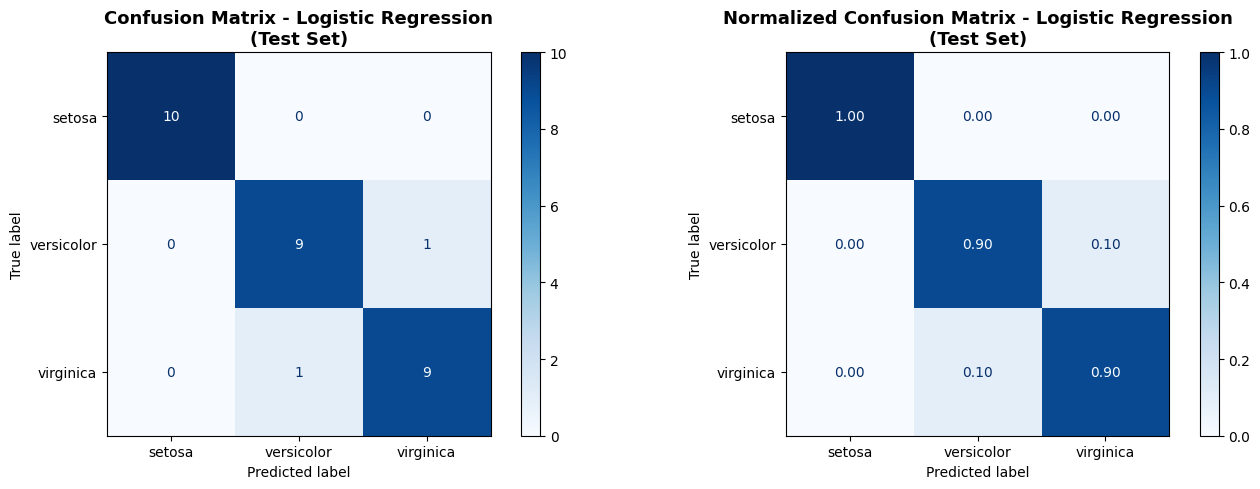

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Count matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'Confusion Matrix - {best_model_name}\n(Test Set)', 
                  fontsize=13, fontweight='bold')
axes[0].grid(False)

# Right: Normalized matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=iris.target_names)
disp_norm.plot(ax=axes[1], cmap='Blues', values_format='.2f')
axes[1].set_title(f'Normalized Confusion Matrix - {best_model_name}\n(Test Set)', 
                  fontsize=13, fontweight='bold')
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 10. Visualize All Models Comparison

Let's create a comprehensive visualization comparing all four models.

/tmp/ipykernel_29086/17039718.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=15, ha='right', fontsize=9)


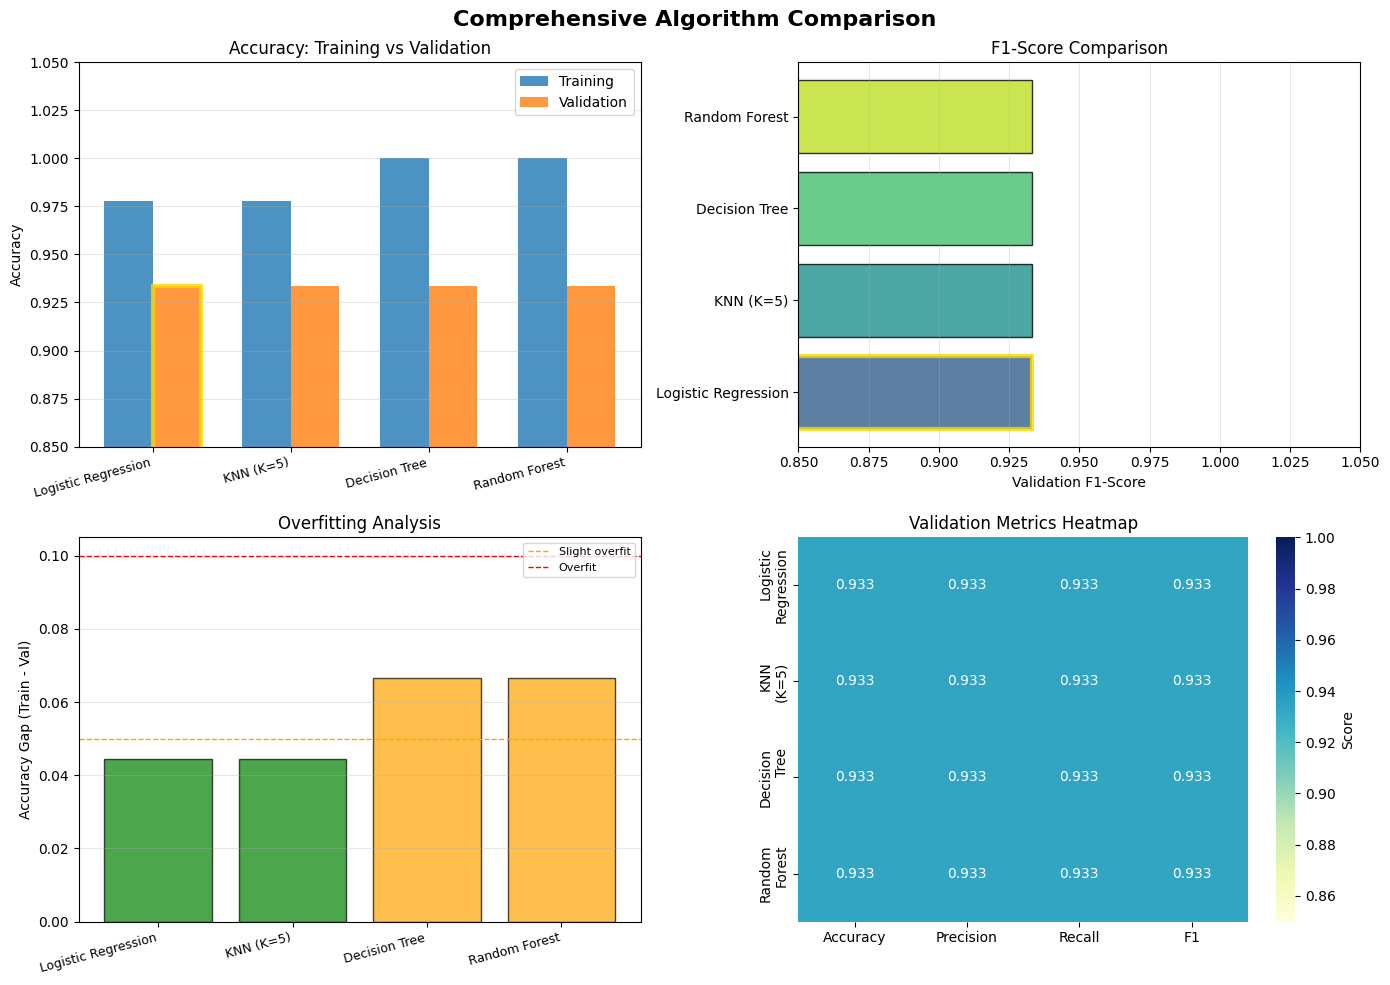


Visualization Key:
  • Top-left: Higher validation accuracy is better
  • Top-right: Higher F1-score indicates better balance
  • Bottom-left: Smaller gap means better generalization
  • Gold borders: Selected model (Logistic Regression)


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comprehensive Algorithm Comparison', fontsize=16, fontweight='bold')

# Prepare data
models = list(results.keys())
train_acc_list = [results[m]['train_acc'] for m in models]
val_acc_list = [results[m]['val_acc'] for m in models]

x = np.arange(len(models))
width = 0.35

# 1. Accuracy Comparison
ax = axes[0, 0]
bars1 = ax.bar(x - width/2, train_acc_list, width, label='Training', alpha=0.8)
bars2 = ax.bar(x + width/2, val_acc_list, width, label='Validation', alpha=0.8)
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy: Training vs Validation')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=9)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0.85, 1.05])

# Highlight best model
best_idx = models.index(best_model_name)
bars2[best_idx].set_edgecolor('gold')
bars2[best_idx].set_linewidth(3)

# 2. F1-Score Comparison
ax = axes[0, 1]
val_f1_list = [results[m]['val_f1'] for m in models]
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(models)))
bars = ax.barh(models, val_f1_list, color=colors, alpha=0.8, edgecolor='black')
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(3)
ax.set_xlabel('Validation F1-Score')
ax.set_title('F1-Score Comparison')
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim([0.85, 1.05])

# 3. Overfitting Analysis
ax = axes[1, 0]
gaps = [results[m]['train_acc'] - results[m]['val_acc'] for m in models]
colors_gap = ['green' if g < 0.05 else 'orange' if g < 0.10 else 'red' for g in gaps]
bars = ax.bar(models, gaps, color=colors_gap, alpha=0.7, edgecolor='black')
ax.set_ylabel('Accuracy Gap (Train - Val)')
ax.set_title('Overfitting Analysis')
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=9)
ax.axhline(y=0.05, color='orange', linestyle='--', lw=1, label='Slight overfit')
ax.axhline(y=0.10, color='red', linestyle='--', lw=1, label='Overfit')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# 4. Metrics Heatmap
ax = axes[1, 1]
metrics_data = []
for name in models:
    metrics_data.append([
        results[name]['val_acc'],
        results[name]['val_precision'],
        results[name]['val_recall'],
        results[name]['val_f1']
    ])

metrics_df = pd.DataFrame(metrics_data, 
                          index=[m.replace(' ', '\n') for m in models],
                          columns=['Accuracy', 'Precision', 'Recall', 'F1'])

sns.heatmap(metrics_df, annot=True, fmt='.3f', cmap='YlGnBu', 
            vmin=0.85, vmax=1.0, ax=ax, cbar_kws={'label': 'Score'})
ax.set_title('Validation Metrics Heatmap')

plt.tight_layout()
plt.show()

print("\nVisualization Key:")
print("  • Top-left: Higher validation accuracy is better")
print("  • Top-right: Higher F1-score indicates better balance")
print("  • Bottom-left: Smaller gap means better generalization")
print(f"  • Gold borders: Selected model ({best_model_name})")

## 11. Key Takeaways

### What We Learned

#### 1. Pipelines Are Essential

**Advantages**:
- ✓ Automate preprocessing + training
- ✓ Prevent errors (automatically uses `transform()` on new data)
- ✓ Cleaner, more maintainable code
- ✓ Easy to save/load entire workflow
- ✓ Fair algorithm comparison with identical preprocessing

**Structure**:
```python
Pipeline([
    ('step1_name', Transformer1()),
    ('step2_name', Transformer2()),
    ('final_name', Estimator())
])
```

#### 2. Proper Validation is Critical

**Three-Way Split**:
- **Training (60%)**: Fit models
- **Validation (20%)**: Compare and select models ← USE THIS for model selection
- **Test (20%)**: Final evaluation ONCE

**Why This Matters**:
- Prevents data leakage from test set
- Gives unbiased performance estimates
- Simulates real-world deployment

#### 3. Different Algorithms, Different Strengths

| Algorithm | Best For | Limitations |
|-----------|----------|-------------|
| **Logistic Regression** | Baseline, linearly separable data | Can't capture non-linear patterns |
| **KNN** | Non-linear boundaries, small datasets | Slow prediction, memory intensive |
| **Decision Tree** | Feature interactions, interpretability | Prone to overfitting |
| **Random Forest** | Best overall accuracy, robust | Less interpretable, slower |

### Common Mistakes to Avoid

❌ **Comparing models on test set then choosing the best**
- This leaks test information into model selection
- Use validation set instead!

❌ **Fitting preprocessor on test data**
- Never call `scaler.fit(X_test)`
- Pipelines handle this automatically!

❌ **Looking at test set multiple times**
- Test set is for final evaluation only
- Use validation set for intermediate checks

❌ **Not checking for overfitting**
- Always compare training vs validation performance
- Large gaps indicate overfitting

### Best Practices Checklist

✓ Use three-way split (train/val/test) when comparing multiple models  
✓ Use pipelines to automate preprocessing  
✓ Compare models on validation set  
✓ Select best model based on validation performance  
✓ Evaluate final model on test set exactly once  
✓ Check for overfitting (train-val gap)  
✓ Use multiple metrics (accuracy, precision, recall, F1)  
✓ Visualize confusion matrix  
✓ Set random_state for reproducibility  
✓ Use stratification for balanced splits  

### The Complete Workflow

```
1. Load data
2. Split: Train (60%) / Validation (20%) / Test (20%)
3. Create pipelines for each algorithm
4. Train all pipelines on training set
5. Evaluate on training and validation sets
6. Select best model based on VALIDATION performance
7. Evaluate selected model on TEST set (once!)
8. Report test performance as final result
```

### Why This Approach is Superior

**Scientific Rigor**:
- Test set remains truly "unseen"
- Performance estimates are unbiased
- Results are trustworthy

**Real-World Applicability**:
- Simulates actual deployment
- Test performance predicts production performance
- Reduces nasty surprises

**Professional Standard**:
- This is how ML is done in industry and research
- Reviewers and employers expect this approach
- Demonstrates understanding of ML fundamentals

### Next Steps

To further improve your ML workflow, explore:

1. **Cross-Validation**: More robust than single train/val split
2. **Hyperparameter Tuning**: Optimize model parameters using GridSearchCV
3. **Feature Engineering**: Create better features
4. **Ensemble Methods**: Combine multiple models
5. **Advanced Algorithms**: Gradient Boosting (XGBoost, LightGBM)

### Final Thoughts

**The methodology matters as much as the algorithm!**

- A simple model with proper validation beats a complex model with data leakage
- Pipelines make your code professional and error-free
- Three-way splits ensure honest performance estimates

**Remember**: The test set is sacred. Touch it only once! 🔒